## Визуализация данных

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Визуализация данных".
* https://numpy.org/doc/stable/reference/generated/numpy.load.html
* https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html
* https://matplotlib.org/stable/gallery/subplots_axes_and_figures/shared_axis_demo.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html
* https://seaborn.pydata.org/examples/index.html
* https://matplotlib.org/stable/tutorials/colors/colormaps.html

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## Задачи для совместного разбора

1. При помощи пакета `pandas_datareader` загрузите данные о ценах акций Apple с 2017-01-01 по 2018-12-31. Визуализируйте временные ряд цен акций.

In [1]:
!pip install pandas_datareader

2. Проанализируйте временной ряд максимальной цены акций на предмет выбросов.

## Лабораторная работа 5.1

__Данная работа подразумевает построение рисунков. В связи с этим задания, для которых не будет виден результат выполнения ячеек (получившиеся рисунки), засчитаны не будут вне зависимости от правильности решения.__

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Настройка стиля
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Визуализация данных при помощи пакета `matplotlib`

__В данном блоке задач не разрешается использовать другие пакеты для визуализации, кроме `matplotlib`.__

1\. В файле `average_ratings.npy` содержится информация о среднем рейтинге 3 рецептов за период с 01.01.2019 по 30.12.2021. При помощи пакета `matplotlib` в _одной системе координат_ (на одной картинке) изобразите три временных ряда, соответствующих средним рейтингам этих рецептов. 

По горизонтальной оси располагается номер дня (0, 1, 2, ...), по вертикальной - средний рейтинг рецептов в этот день. 

Названия рецептов и их индексы в файле `average_ratings.npy`:
```
0: waffle iron french toast
1: zwetschgenkuchen bavarian plum cake
2: lime tea
```

Результатом работы является визуализация, на которой:
* добавлена подпись горизонтальной оси с текстом "Номер дня"
* добавлена подпись вертикальной оси с текстом "Средний рейтинг"
* добавлена подпись рисунка с текстом "Изменение среднего рейтинга трех рецептов"
* каждый из временных рядов имеет уникальный цвет
* добавлена легенда, на которой отображается название каждого из рецептов

_Примечание_ : для считывания файла воспользуйтесь функцией `np.load`.

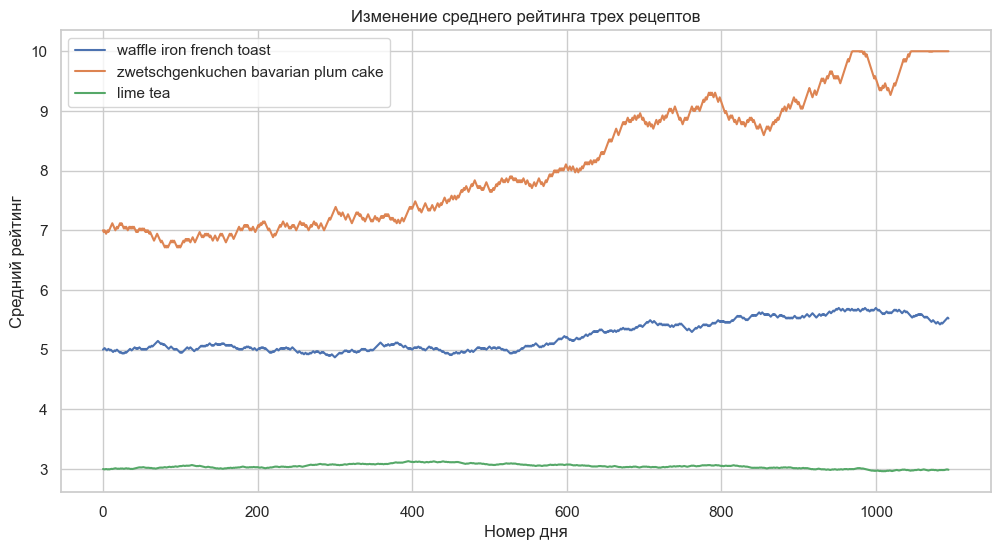

In [4]:
ratings = np.load('/Users/iliaegorov/Projects/fa/datat/05_graphics/data/average_ratings.npy')

days = np.arange(ratings.shape[1]) # Номер дня от 0 до N

recipe_names = [
    "waffle iron french toast",
    "zwetschgenkuchen bavarian plum cake",
    "lime tea"
]

plt.figure(figsize=(12, 6))

for i in range(ratings.shape[0]):
    plt.plot(days, ratings[i], label=recipe_names[i])

plt.xlabel("Номер дня")
plt.ylabel("Средний рейтинг")
plt.title("Изменение среднего рейтинга трех рецептов")
plt.legend()
plt.grid(True)
plt.show()

2\. Измените визуализацию, полученную в задании 1, таким образом, чтобы по горизонтальной оси отображались года, а между двумя соседними годами располагались засечки, соответствующие месяцам. Для этого создайте диапазон дат от 01.01.2019 по 30.12.2021 с шагом в один день (например, [вот так](https://pandas.pydata.org/docs/reference/api/pandas.date_range.html)) и используйте этот диапазон при вызове метода `plot`. Далее настройте `major_locator` и `minor_locator` горизонтальной оси (подробнее см. [здесь](https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html))

Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 1. Измените подпись горизонтальной оси, написав там слово "Дата".


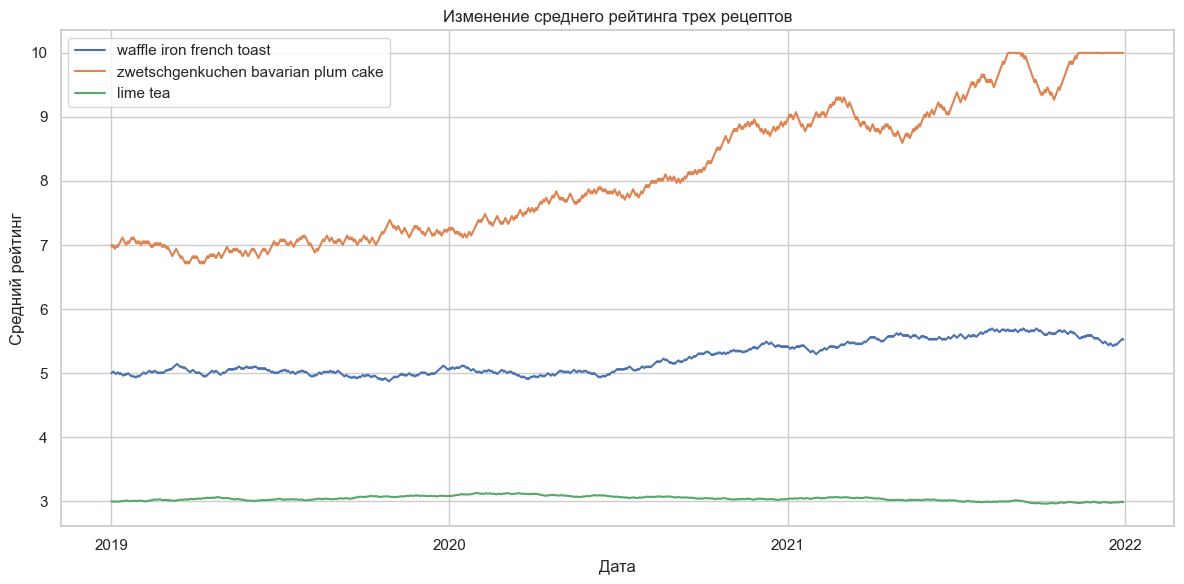

In [6]:
start_date = '2019-01-01'
end_date = '2021-12-30'
dates = pd.date_range(start=start_date, end=end_date, freq='D')

plt.figure(figsize=(12, 6))

for i in range(ratings.shape[0]):
    plt.plot(dates, ratings[i], label=recipe_names[i])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.xlabel("Дата")
plt.ylabel("Средний рейтинг")
plt.title("Изменение среднего рейтинга трех рецептов")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3\. Измените визуализацию, полученную в задании 2, разбив одну картинку на три, расположенных друг под другом. Три изображения должны иметь одну общую горизонтальную ось (каждое изображение засечки в нижней части, но значения этих засечек находятся только под самым нижним изображением). Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 2.

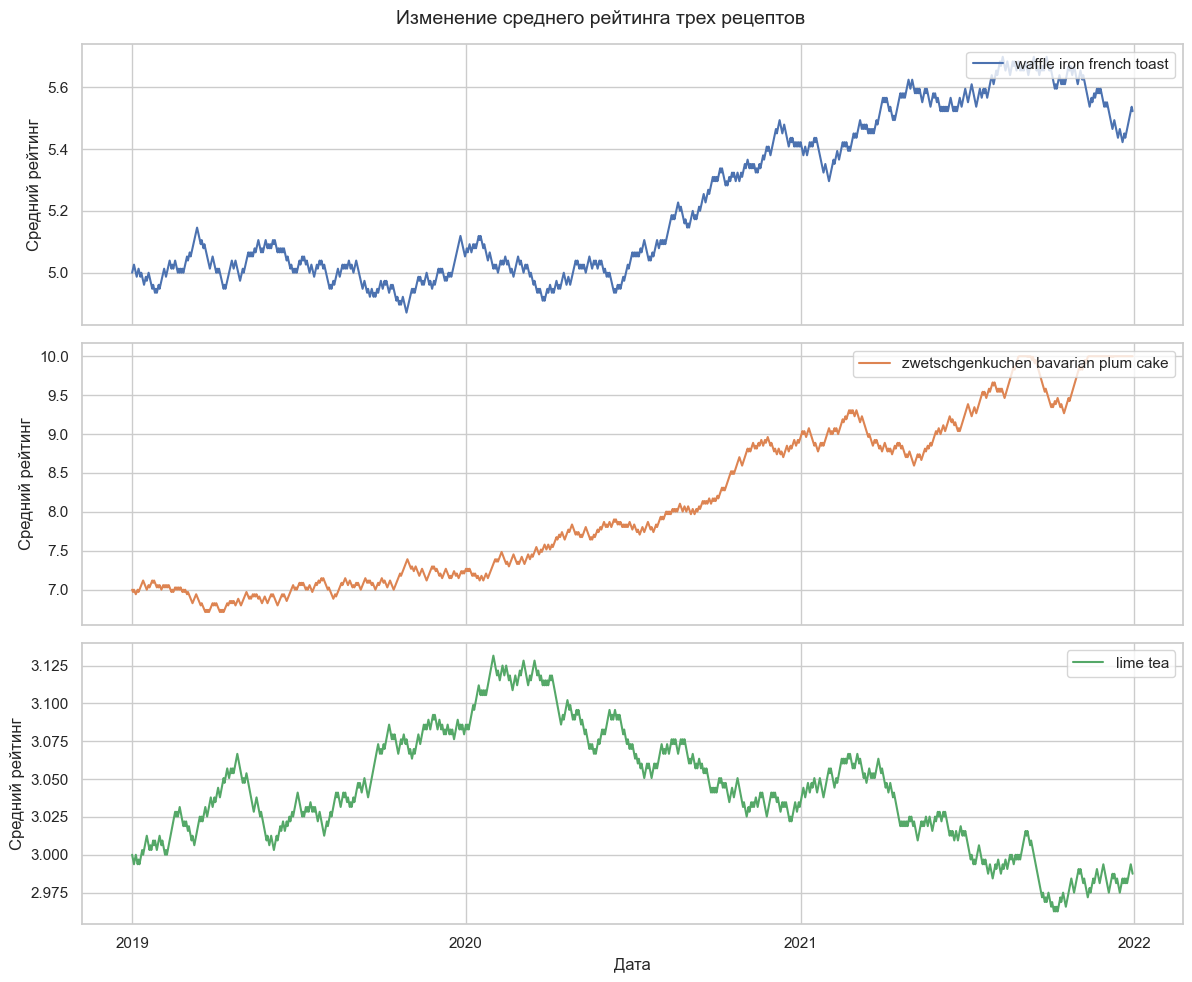

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i in range(ratings.shape[0]):
    axes[i].plot(dates, ratings[i], color='C{}'.format(i), label=recipe_names[i])
    axes[i].set_ylabel("Средний рейтинг")
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_minor_locator(mdates.MonthLocator())

plt.xlabel("Дата")
plt.suptitle("Изменение среднего рейтинга трех рецептов", fontsize=14)
plt.tight_layout()
plt.show()

4\. В файле `visitors.npy` представлена информация о количестве посетителей сайта в течении первых 100 дней после объявления сайтом акции. Постройте график изменения количества пользователей в зависимости от дня в двух вариантах, расположенных рядом по горизонтале. В обоих случаях изобразите график в виде ломаной, но в первом случае оставьте линейный масштаб осей, а во втором случае сделайте вертикальную ось в логарифмическом масштабе. Добавьте на обе картинки подпись над этим графиком к текстом $y(x)=\lambda e^{-\lambda x}$

Добавьте на оба изображения красную горизонтальную линию на уровне $y=100$. Добавьте на обе картинки подпись над этой линией с текстом $y(x)=100$

Добавьте на оба изображения подписи осей; горизонтальную ось подпишите текстом "Количество дней с момента акции", вертикальную - "Число посетителей".

Добавьте общий заголовок для фигуры с текстом "Изменение количества пользователей в линейном и логарифмическом масштабе".


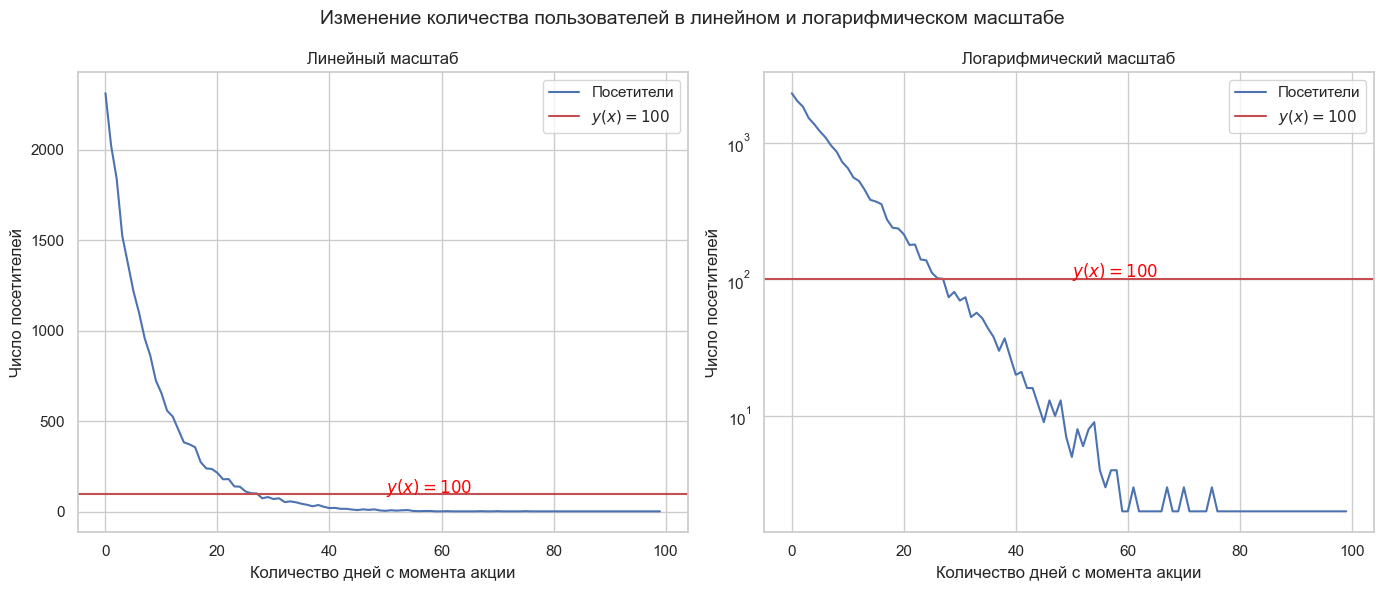

In [9]:
visitors = np.load('/Users/iliaegorov/Projects/fa/datat/05_graphics/data/visitors.npy')


days_visitors = np.arange(len(visitors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(days_visitors, visitors, label='Посетители')
ax1.axhline(y=100, color='r', linestyle='-', label='$y(x)=100$')
ax1.text(50, 105, '$y(x)=100$', color='red') # Примерное позиционирование подписи
ax1.set_xlabel("Количество дней с момента акции")
ax1.set_ylabel("Число посетителей")
ax1.set_title("Линейный масштаб")
ax1.legend()
ax1.grid(True)

ax2.plot(days_visitors, visitors, label='Посетители')
ax2.axhline(y=100, color='r', linestyle='-', label='$y(x)=100$')
ax2.text(50, 105, '$y(x)=100$', color='red')
ax2.set_yscale('log')
ax2.set_xlabel("Количество дней с момента акции")
ax2.set_ylabel("Число посетителей")
ax2.set_title("Логарифмический масштаб")
ax2.legend()
ax2.grid(True)

plt.suptitle("Изменение количества пользователей в линейном и логарифмическом масштабе", fontsize=14)
plt.tight_layout()
plt.show()

## Лабораторная работа 5.2

### Визуализация данных на основе структур `pandas`.

Для продолжения работы загрузите таблицы recipes и reviews (__ЛР2__)

In [14]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

file_path = '/Users/iliaegorov/Projects/fa/datat/02_pandas/data/recipes_sample.csv'


df_recipes = pd.read_csv(file_path, header=None, on_bad_lines='warn')

num_cols = df_recipes.shape[1]
print(f"Файл прочитан. Количество колонок: {num_cols}")

if num_cols == 8:
    df_recipes.columns = ['name', 'minutes', 'n_steps', 'n_ingredients', 'date', 'rating', 'description', 'extra']
    if 'extra' in df_recipes.columns:
        df_recipes.drop('extra', axis=1, inplace=True)
elif num_cols == 7:
    df_recipes.columns = ['name', 'minutes', 'n_steps', 'n_ingredients', 'date', 'rating', 'description']
else:
    print(f"Внимание: Нестандартное количество колонок ({num_cols}). Использую первые 7.")
    df_recipes = df_recipes.iloc[:, :7]
    df_recipes.columns = ['name', 'minutes', 'n_steps', 'n_ingredients', 'date', 'rating', 'description']


df_recipes['minutes'] = pd.to_numeric(df_recipes['minutes'], errors='coerce')
df_recipes['n_steps'] = pd.to_numeric(df_recipes['n_steps'], errors='coerce')
df_recipes['n_ingredients'] = pd.to_numeric(df_recipes['n_ingredients'], errors='coerce')
df_recipes['rating'] = pd.to_numeric(df_recipes['rating'], errors='coerce')
df_recipes['date'] = pd.to_datetime(df_recipes['date'], errors='coerce')

df_recipes.dropna(subset=['minutes', 'n_steps', 'n_ingredients'], inplace=True)

def categorize_duration(minutes):
    if minutes < 5:
        return 'short'
    elif 5 <= minutes < 50:
        return 'medium'
    else:
        return 'long'

df_recipes['duration_cat'] = df_recipes['minutes'].apply(categorize_duration)

print("Данные загружены и обработаны. Размер:", df_recipes.shape)
print(df_recipes.head())

Файл прочитан. Количество колонок: 8
Данные загружены и обработаны. Размер: (30000, 8)
                                       name  minutes  n_steps  n_ingredients  \
1     george s at the cove  black bean soup  44123.0     90.0        35193.0   
2        healthy for them  yogurt popsicles  67664.0     10.0        91970.0   
3              i can t believe it s spinach  38798.0     30.0         1533.0   
4                      italian  gut busters  35173.0     45.0        22724.0   
5  love is in the air  beef fondue   sauces  84797.0     25.0         4470.0   

        date  rating                                        description  \
1 2002-10-25     NaN  an original recipe created by chef scott meska...   
2 2003-07-26     NaN  my children and their friends ask for my homem...   
3 2002-08-29     NaN            these were so go, it surprised even me.   
4 2002-07-27     NaN  my sister-in-law made these for us at a family...   
5 2004-02-23     4.0  i think a fondue is a very romantic

/var/folders/xw/k96s6rms38jflh8n8j0cpznw0000gn/T/ipykernel_14849/2594802384.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_recipes['date'] = pd.to_datetime(df_recipes['date'], errors='coerce')


5\. Назовем рецепты короткими, если они занимают строго меньше 5 минут; средними, если они занимают от 5 до 50 минут (не включая 50), и длинными, если они занимают от 50 минут и больше. Сгруппируйте все рецепты по данному признаку и для каждой группы посчитайте 2 величины: среднее количество шагов рецептов в группе и размер группы. При помощи методов структур `pandas` постройте столбчатую диаграмму, где каждый столбец означает группу (короткие, средние или длинные рецепты), а высота столбца обозначает среднее количество шагов рецептов в группе. Рядом по горизонтали разместите круговую диаграмму, на которой отображены размеры каждой из групп.

Добавьте следующие подписи:
* по горизонтальной оси под столбчатой диаграммой напишите "Группа рецептов"
* по вертикальной оси слева от столбчатой диаграммы напишите "Средняя длительность"
* над круговой диаграммой напишите "Размеры групп рецептов"

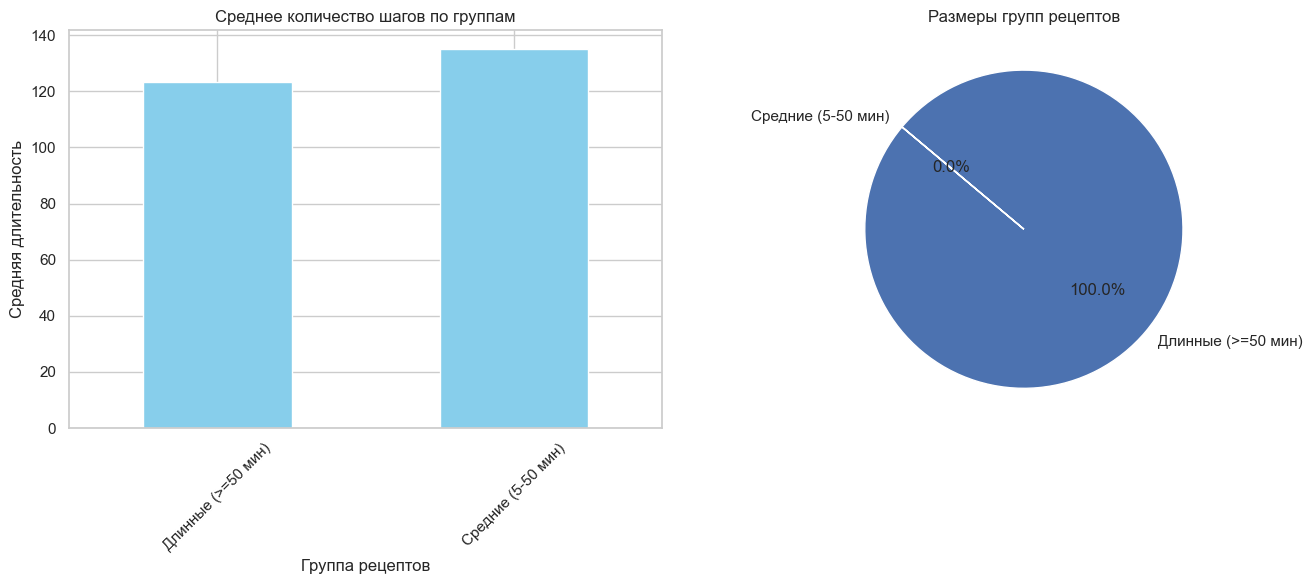

In [15]:
grouped = df_recipes.groupby('duration_cat').agg(
    avg_steps=('n_steps', 'mean'),
    count=('name', 'count')
).reset_index()

grouped['duration_cat'] = grouped['duration_cat'].map({
    'short': 'Короткие (<5 мин)',
    'medium': 'Средние (5-50 мин)',
    'long': 'Длинные (>=50 мин)'
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

grouped.plot.bar(x='duration_cat', y='avg_steps', ax=ax1, color='skyblue', legend=False)
ax1.set_xlabel("Группа рецептов")
ax1.set_ylabel("Средняя длительность") # По заданию так, хотя логичнее "Среднее кол-во шагов"
ax1.set_title("Среднее количество шагов по группам")
ax1.tick_params(axis='x', rotation=45)

ax2.pie(grouped['count'], labels=grouped['duration_cat'], autopct='%1.1f%%', startangle=140)
ax2.set_title("Размеры групп рецептов")

plt.tight_layout()
plt.show()

6\. Из всего множества отзывов оставьте только те, которые были даны в 2008 и 2009 годах. Воспользовавшись возможностями метода `pd.DataFrame.plot.hist`, постройте 2 гистограммы столбца `rating`. Гистограммы должны быть расположены рядом по горизонтали. Левая гистограмма соотвествует 2008 году, правая - 2009 году. Добавьте общую подпись для рисунка с текстом "Гистограммы рейтинга отзывов в 2008 и 2009 годах". Добейтесь того, чтобы подпись вертикальной оси правого рисунка не "наезжала" на левый рисунок.

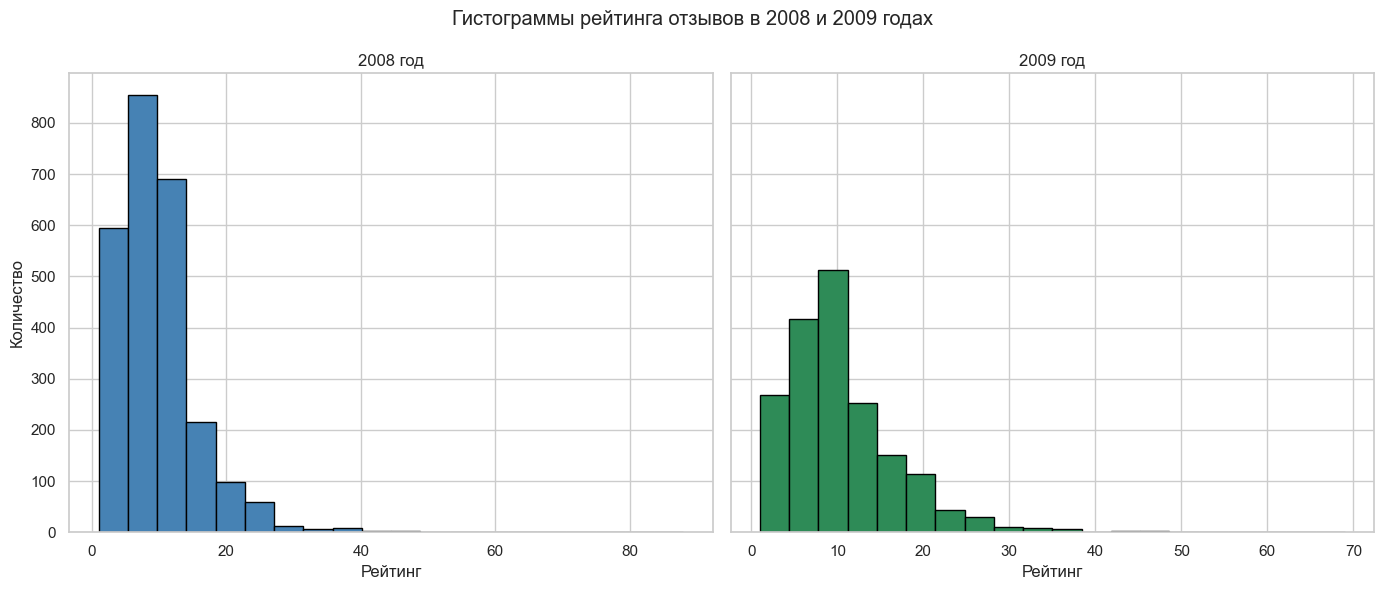

In [17]:
df_2008 = df_recipes[df_recipes['date'].dt.year == 2008]
df_2009 = df_recipes[df_recipes['date'].dt.year == 2009]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

ax1.hist(df_2008['rating'].dropna(), bins=20, color='steelblue', edgecolor='black')
ax1.set_title("2008 год")
ax1.set_xlabel("Рейтинг")
ax1.set_ylabel("Количество")

ax2.hist(df_2009['rating'].dropna(), bins=20, color='seagreen', edgecolor='black')
ax2.set_title("2009 год")
ax2.set_xlabel("Рейтинг")

plt.suptitle("Гистограммы рейтинга отзывов в 2008 и 2009 годах")
plt.tight_layout()
plt.show()

### Визуализация данных при помощи пакета `seaborn`

7\. При помощи пакета `seaborn` постройте диаграмму рассеяния двух столбцов из таблицы `recipes`: `n_steps` и `n_ingredients`. Укажите в качестве группирующей переменной (hue) категориальную длительность рецепта (короткий, средний или длинные; см. задание 5). 

Добавьте заголовок рисунка "Диаграмма рассеяния n_steps и n_ingredients"

Прокомментируйте, наблюдается ли визуально линейная зависимость между двумя этими переменными. Ответ оставьте в виде текстовой ячейки под изображением.

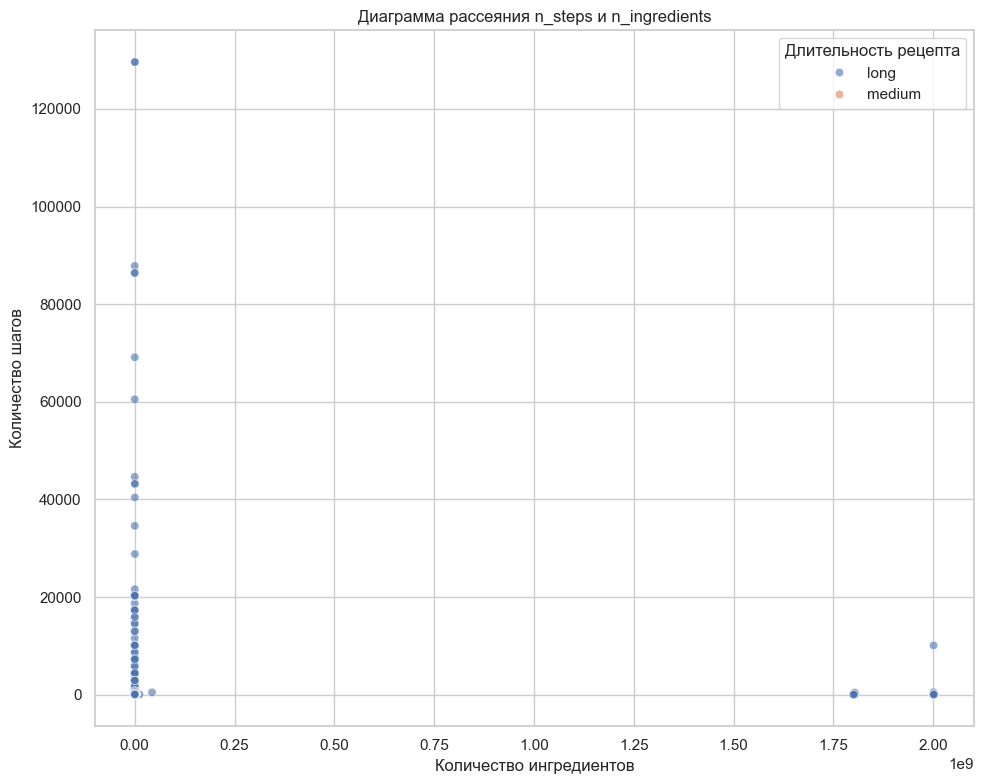

In [19]:
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(data=df_recipes, x='n_ingredients', y='n_steps', hue='duration_cat', alpha=0.6)

plt.title("Диаграмма рассеяния n_steps и n_ingredients")
plt.xlabel("Количество ингредиентов")
plt.ylabel("Количество шагов")
plt.legend(title="Длительность рецепта")
plt.tight_layout()
plt.show()

8\. Объедините две таблицы `recipes` и `reviews` и постройте корреляционную матрицу на основе столбцов "minutes", "n_steps", "n_ingredients" и "rating". При помощи пакета `seaborn` визуализируйте полученную матрицу в виде тепловой карты (heatmap). 

Добавьте в ячейки тепловой карты подписи (значения к-та корреляции). Измените цветовую палитру на `YlOrRd`. 

Добавьте заголовок рисунка "Корреляционная матрица числовых столбцов таблиц recipes и reviews"

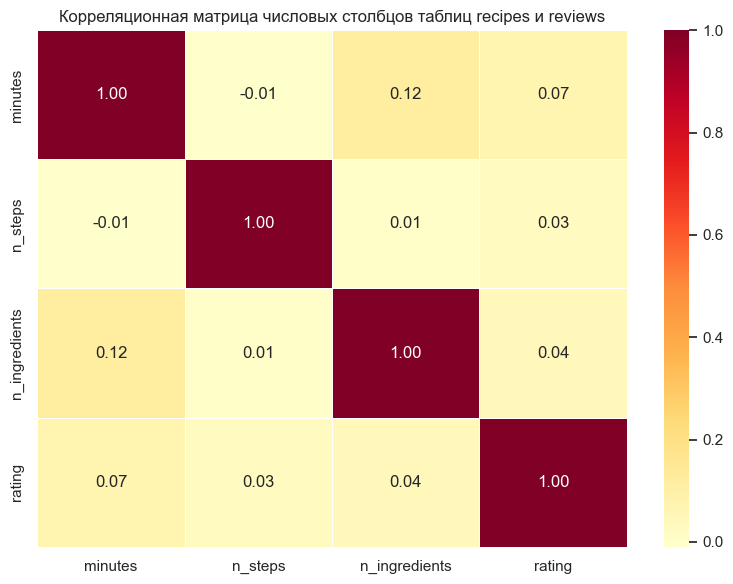

In [20]:
cols_for_corr = ['minutes', 'n_steps', 'n_ingredients', 'rating']
df_corr = df_recipes[cols_for_corr].dropna()

corr_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=.5)

plt.title("Корреляционная матрица числовых столбцов таблиц recipes и reviews")
plt.tight_layout()
plt.show()